In [1]:
import numpy as np
from pprint import pprint

In [2]:
dt = 5.0  # Delta t em segundos
z_0 = np.array([[10000.0], [200.0]])  # Medição inicial [Alcance, Velocidade]

sigma_r = 4.0  # Desvio padrão do alcance
sigma_v = 0.5  # Desvio padrão da velocidade
sigma_a = 0.2  # Desvio padrão da aceleração aleatória (ruído do processo)

In [3]:
# A estimativa inicial é igual à primeira medição
x_0_0 = z_0

# A matriz de covariância inicial P é igual à matriz de incerteza da medição R
R_0 = np.array([[sigma_r**2, 0], [0, sigma_v**2]])
P_0_0 = R_0

pprint("Estado Inicial (x_0_0):")
pprint(x_0_0)
pprint("Covariância Inicial (P_0_0):")
pprint(P_0_0)

'Estado Inicial (x_0_0):'
array([[10000.],
       [  200.]])
'Covariância Inicial (P_0_0):'
array([[16.  ,  0.  ],
       [ 0.  ,  0.25]])


In [4]:
# Matriz de Transição de Estado (F)
F = np.array([[1.0, dt], [0.0, 1.0]])

# Matriz de Ruído do Processo (Q)
var_a = sigma_a**2
Q = np.array([[(dt**4) / 4, (dt**3) / 2], [(dt**3) / 2, dt**2]]) * var_a

pprint("Matriz de Transição de Estado (F):")
pprint(F)
pprint("Matriz de Ruído do Processo (Q):")
pprint(Q)

'Matriz de Transição de Estado (F):'
array([[1., 5.],
       [0., 1.]])
'Matriz de Ruído do Processo (Q):'
array([[6.25, 2.5 ],
       [2.5 , 1.  ]])


In [5]:
# 1. Extrapolação do Estado: x_1_0 = F * x_0_0
x_1_0 = np.matmul(F, x_0_0)

# 2. Extrapolação da Covariância: P_1_0 = F * P_0_0 * F^T + Q
P_1_0 = np.dot(np.dot(F, P_0_0), F.T) + Q

pprint("ESTADO PREVISTO PARA t1 (x_1_0):")
pprint(x_1_0)
pprint("COVARIÂNCIA PREVISTA PARA t1 (P_1_0):")
pprint(P_1_0)

'ESTADO PREVISTO PARA t1 (x_1_0):'
array([[11000.],
       [  200.]])
'COVARIÂNCIA PREVISTA PARA t1 (P_1_0):'
array([[28.5 ,  3.75],
       [ 3.75,  1.25]])


In [6]:
# Iteração 1: atualização do filtro
z_1 = np.array([[11020.0], [202]])  # Medição no instante t1

sigma_r_1 = 6.0  # Desvio padrão do alcance no instante t1
sigma_v_1 = 1.5  # Desvio padrão da velocidade no instante t1

In [7]:
# Matriz de covariância da medição no instante t1
R_1 = np.array([[sigma_r_1**2, 0], [0, sigma_v_1**2]])
I = np.eye(2)  # Matriz identidade

K_1_0 = np.dot(P_1_0, I)  # P_1_0 * I
K_1_1 = np.dot(np.dot(I, P_1_0), I)  # I * P_1_0 * I
K_1_2 = np.add(K_1_1, R_1)  # I * P_1_0 * I + R_1
K_1_3 = np.linalg.inv(K_1_2)  # Inversão da matriz resultante
K_1 = np.dot(
    K_1_0,
    K_1_3,
)  # Cálculo do ganho de Kalman K_1

pprint("GANHO DE KALMAN (K_1):")
pprint(K_1)

'GANHO DE KALMAN (K_1):'
array([[0.40478299, 0.63773251],
       [0.03985828, 0.31443756]])


In [8]:
# Informação nova
Inf_Nov = np.subtract(z_1, x_1_0)
Cor = np.dot(K_1, Inf_Nov)  # Aplicando a correção

x_1_1 = np.add(x_1_0, Cor)
pprint("INFORMAÇÃO NOVA (z_1 - x_1_0):")
pprint(Inf_Nov)
pprint(Cor)
pprint(x_1_1)

'INFORMAÇÃO NOVA (z_1 - x_1_0):'
array([[20.],
       [ 2.]])
array([[9.37112489],
       [1.42604074]])
array([[11009.37112489],
       [  201.42604074]])


In [9]:
# Quantificação da Incerteza da Estimativa Atualizada
# 1. Forma de Joseph Simplificada
P_1_1_ = np.dot(np.subtract(I, K_1), P_1_0)
pprint("COVARIÂNCIA ATUALIZADA (P_1_1) - Forma de Joseph Simplificada:")
pprint(P_1_1_)

# 2. Forma de Joseph Completa
P_1_1_0 = np.matrix_transpose(np.subtract(I, np.dot(K_1, I)))
P_1_1_1 = np.dot(np.dot(K_1, R_1), np.matrix_transpose(K_1))
P_1_1 = np.dot(P_1_1_, P_1_1_0) + P_1_1_1
pprint(P_1_1)

'COVARIÂNCIA ATUALIZADA (P_1_1) - Forma de Joseph Simplificada:'
array([[14.57218778,  1.43489814],
       [ 1.43489814,  0.7074845 ]])
array([[14.57218778,  1.43489814],
       [ 1.43489814,  0.7074845 ]])


## Análise da Implementação


### Variáveis

| Variável | Dimensão | Descrição |
|---|---|---|
| `dt` | escalar | Intervalo de tempo entre medições (5 s) |
| `z_0`, `z_1` | (2×1) | Medições do radar em t₀ e t₁ |
| `sigma_r`, `sigma_v` | escalares | Desvios padrão da medição (alcance, velocidade) |
| `sigma_a` | escalar | Desvio padrão da aceleração aleatória (ruído do processo) |
| `R_0`, `R_1` | (2×2) | Matrizes de covariância da medição |
| `F` | (2×2) | Matriz de transição de estado (modelo cinemático) |
| `Q` | (2×2) | Matriz de covariância do ruído do processo |
| `x_0_0` | (2×1) | Estado inicial (igual à medição) |
| `P_0_0` | (2×2) | Covariância inicial (igual a R₀) |
| `x_1_0` | (2×1) | Estado **predito** pelo modelo dinâmico em t₁ |
| `P_1_0` | (2×2) | Covariância **predita** (propagação de F·P·Fᵀ + Q) |
| `K_1` | (2×2) | **Ganho de Kalman** — pondera confiança entre modelo e medição |
| `x_1_1` | (2×1) | Estado **atualizado** (estimativa final pós-medição) |
| `P_1_1_`, `P_1_1` | (2×2) | Covariância **atualizada** (Forma de Joseph simplificada e completa) |

### Métodos/Etapas

1. **Inicialização** — Estado e covariância iguais à primeira medição.
2. **Predição (time update)** — Projeta o estado para o próximo instante usando `F` e aumenta a incerteza com `Q`:
   - `x_1_0 = F · x_0_0`
   - `P_1_0 = F · P_0_0 · Fᵀ + Q`
3. **Cálculo do Ganho de Kalman** — `K = P · (P + R)⁻¹` (equivalente a `P·Hᵀ·(H·P·Hᵀ+R)⁻¹` com H = I).
4. **Atualização (measurement update)** — Corrige a predição com a nova medição ponderada por K:
   - Inovação: `z₁ − x₁₀`
   - Correção: `K · inovação`
   - Estado atualizado: `x₁₁ = x₁₀ + correção`
5. **Atualização da covariância** — Duas formas equivalentes de Joseph:
   - **Simplificada:** `P = (I − K) · P₁₀`
   - **Completa:** `P = (I−K)·P₁₀·(I−K)ᵀ + K·R·Kᵀ` (numericamente mais estável)

### Observações
- A matriz de identidade `I` é usada como matriz de observação `H` (o radar mede alcance e velocidade diretamente).
- O ganho de Kalman resultante (`K_1`) mostra que o filtro confia mais na medição para o alcance (≈0.40) e no modelo para a velocidade (≈0.31), equilibrando ambas as fontes.
- Após a atualização, ambas as incertezas (variâncias em `P_1_1`) são **menores** que as da predição e da medição isoladas — demonstrando o benefício da fusão sensorial do filtro.

## Resumo da Implementação

Este exemplo implementa um **Filtro de Kalman para um radar unidimensional** que mede alcance (distância) e velocidade de uma aeronave.

### Etapas executadas

1. **Medição inicial** ($t_0$):
   - Alcance: $z_r = 10000\,\text{m}$, Velocidade: $z_v = 200\,\text{m/s}$
   - Incertezas: $\sigma_r = 4\,\text{m}$, $\sigma_v = 0.5\,\text{m/s}$
   - Estado inicial: $\hat{x}_{0|0} = z_0$, covariância: $P_{0|0} = R$

2. **Modelo dinâmico** ( $\Delta t = 5\,\text{s}$ ):
   - Matriz de transição: $F = \begin{bmatrix}1 & \Delta t \\ 0 & 1\end{bmatrix}$
   - Ruído do processo ($\sigma_a = 0.2\,\text{m/s}^2$): $Q = \sigma_a^2 \begin{bmatrix}\Delta t^4/4 & \Delta t^3/2 \\ \Delta t^3/2 & \Delta t^2\end{bmatrix}$

3. **Predição** ($t_0 \to t_1$):
   - Estado previsto: $\hat{x}_{1|0} = \begin{bmatrix}11000\,\text{m} \\ 200\,\text{m/s}\end{bmatrix}$
   - Covariância prevista: $P_{1|0} = \begin{bmatrix}28.5 & 3.75 \\ 3.75 & 1.25\end{bmatrix}$

4. **Atualização** (medição em $t_1$: $11020\,\text{m}$, $202\,\text{m/s}$):
   - Ganho de Kalman: $K_1 = P_{1|0} \, (P_{1|0} + R_1)^{-1}$
   - Estado atualizado: $\hat{x}_{1|1} = \begin{bmatrix}11009.37\,\text{m} \\ 201.43\,\text{m/s}\end{bmatrix}$
   - Covariância atualizada (ambas as formas equivalentes):
   $$
   P_{1|1} = \begin{bmatrix}
   14.57 & 1.43 \\
   1.43 & 0.71
   \end{bmatrix}
   $$



In [10]:
import matplotlib.pyplot as plt
import numpy as np

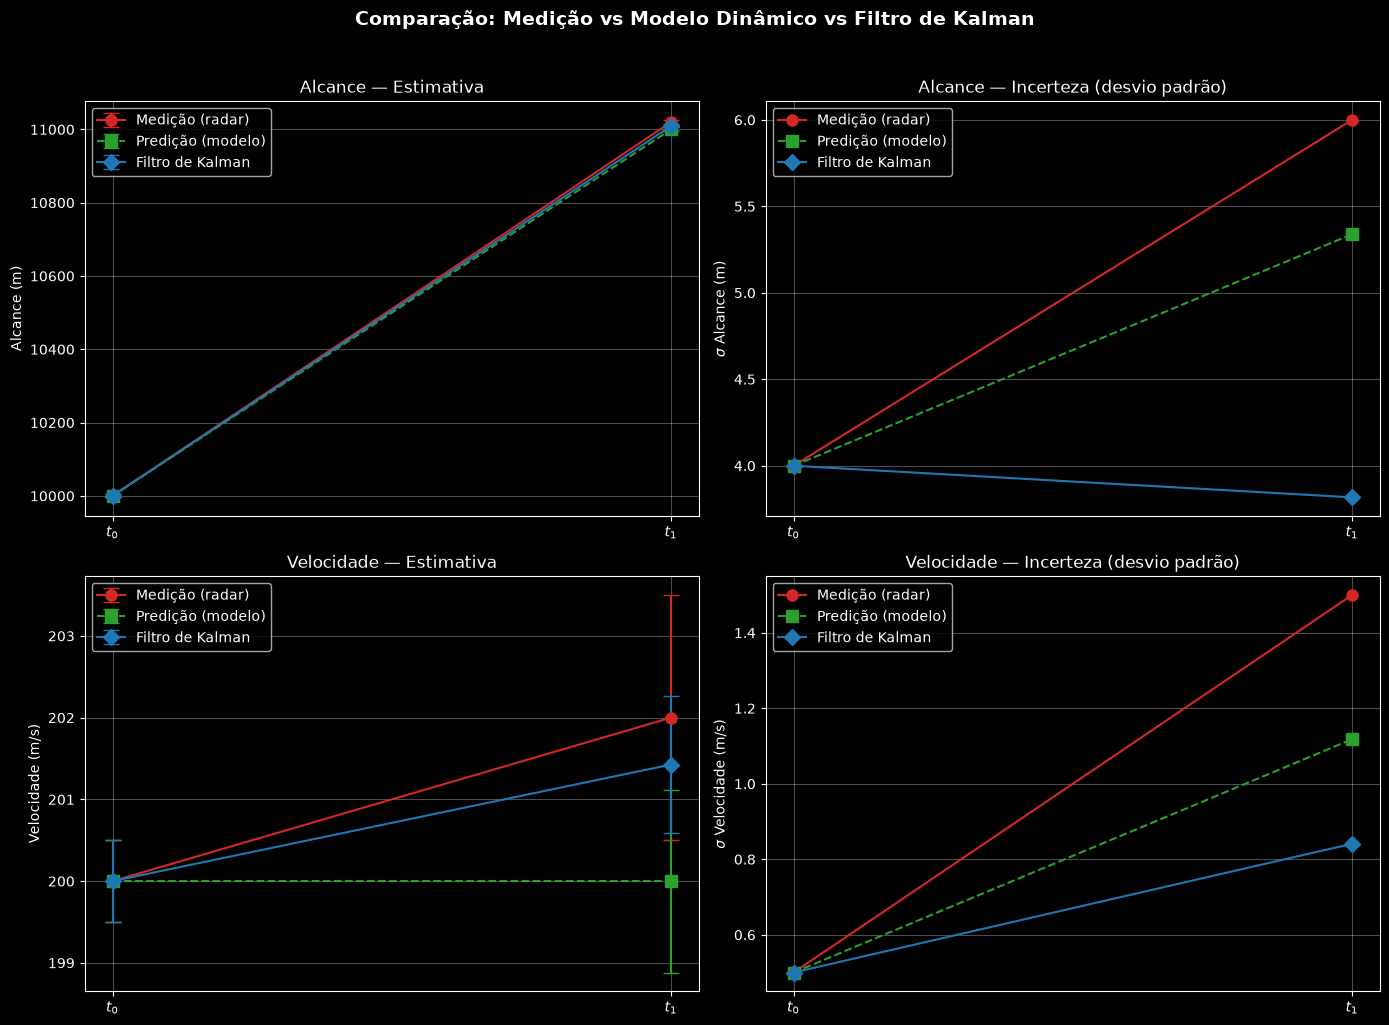

In [11]:
# Dados do exemplo
labels = [r"$t_0$", r"$t_1$"]

# Alcance (m)
range_meas = [z_0[0, 0], z_1[0, 0]]
range_pred = [z_0[0, 0], x_1_0[0, 0]]   # em t0 = z_0, em t1 = predição
range_kf   = [z_0[0, 0], x_1_1[0, 0]]   # em t0 = z_0, em t1 = KF

# Velocidade (m/s)
vel_meas = [z_0[1, 0], z_1[1, 0]]
vel_pred = [z_0[1, 0], x_1_0[1, 0]]
vel_kf   = [z_0[1, 0], x_1_1[1, 0]]

# Incertezas — desvio padrão (sqrt da diagonal das covariâncias)
# Medição: std extraído de R
std_meas_range = [np.sqrt(R_0[0, 0]), np.sqrt(R_1[0, 0])]
std_meas_vel   = [np.sqrt(R_0[1, 1]), np.sqrt(R_1[1, 1])]

# Predição: std extraído de P_1_0 (em t0 usamos P_0_0)
std_pred_range = [np.sqrt(P_0_0[0, 0]), np.sqrt(P_1_0[0, 0])]
std_pred_vel   = [np.sqrt(P_0_0[1, 1]), np.sqrt(P_1_0[1, 1])]

# Kalman: std extraído de P_1_1 (em t0 usamos P_0_0)
std_kf_range = [np.sqrt(P_0_0[0, 0]), np.sqrt(P_1_1[0, 0])]
std_kf_vel   = [np.sqrt(P_0_0[1, 1]), np.sqrt(P_1_1[1, 1])]

x = [0, 1]  # posições no eixo x

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- ALCANCE (valor) ----
ax = axes[0, 0]
ax.errorbar(x, range_meas, yerr=std_meas_range, fmt="o-", capsize=6,
            label="Medição (radar)", color="tab:red", markersize=8)
ax.errorbar(x, range_pred, yerr=std_pred_range, fmt="s--", capsize=6,
            label="Predição (modelo)", color="tab:green", markersize=8)
ax.errorbar(x, range_kf, yerr=std_kf_range, fmt="D-", capsize=6,
            label="Filtro de Kalman", color="tab:blue", markersize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Alcance (m)")
ax.set_title("Alcance — Estimativa")
ax.legend()
ax.grid(True, alpha=0.3)

# ---- VELOCIDADE (valor) ----
ax = axes[1, 0]
ax.errorbar(x, vel_meas, yerr=std_meas_vel, fmt="o-", capsize=6,
            label="Medição (radar)", color="tab:red", markersize=8)
ax.errorbar(x, vel_pred, yerr=std_pred_vel, fmt="s--", capsize=6,
            label="Predição (modelo)", color="tab:green", markersize=8)
ax.errorbar(x, vel_kf, yerr=std_kf_vel, fmt="D-", capsize=6,
            label="Filtro de Kalman", color="tab:blue", markersize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Velocidade (m/s)")
ax.set_title("Velocidade — Estimativa")
ax.legend()
ax.grid(True, alpha=0.3)

# ---- INCERTEZA DO ALCANCE (apenas std) ----
ax = axes[0, 1]
ax.plot(x, std_meas_range, "o-", label="Medição (radar)", color="tab:red", markersize=8)
ax.plot(x, std_pred_range, "s--", label="Predição (modelo)", color="tab:green", markersize=8)
ax.plot(x, std_kf_range, "D-", label="Filtro de Kalman", color="tab:blue", markersize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(r"$\sigma$ Alcance (m)")
ax.set_title("Alcance — Incerteza (desvio padrão)")
ax.legend()
ax.grid(True, alpha=0.3)

# ---- INCERTEZA DA VELOCIDADE (apenas std) ----
ax = axes[1, 1]
ax.plot(x, std_meas_vel, "o-", label="Medição (radar)", color="tab:red", markersize=8)
ax.plot(x, std_pred_vel, "s--", label="Predição (modelo)", color="tab:green", markersize=8)
ax.plot(x, std_kf_vel, "D-", label="Filtro de Kalman", color="tab:blue", markersize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(r"$\sigma$ Velocidade (m/s)")
ax.set_title("Velocidade — Incerteza (desvio padrão)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Comparação: Medição vs Modelo Dinâmico vs Filtro de Kalman",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()